# Image Support

Claude can analyze images you include in a message — describe them, compare them, count objects, run complex visual analysis. You send an **image block** alongside your text block in a user message.

**Limits to keep in mind:**

| Limit | Value |
|-------|-------|
| Images per request | up to 100 (across all messages) |
| Max size per image | 5 MB |
| Max dimension (single image) | 8000px |
| Max dimension (multiple images) | 2000px |
| Source types | base64 **or** a URL |
| Token cost | ≈ `(width_px × height_px) / 750` |

> Uses `claude-haiku-4-5-20251001` (vision + `temperature=1.0` both fine). The base64 image-block shape is unchanged from the course. Sample satellite images are in `./images/`.

## Setup

In [1]:
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())

import os
import base64
from anthropic import Anthropic
from anthropic.types import Message

client = Anthropic()
model = "claude-haiku-4-5-20251001"


def add_user_message(messages, message):
    messages.append({
        "role": "user",
        "content": message.content if isinstance(message, Message) else message,
    })


def add_assistant_message(messages, message):
    messages.append({
        "role": "assistant",
        "content": message.content if isinstance(message, Message) else message,
    })


def chat(messages, system=None, temperature=1.0, stop_sequences=[], tools=None):
    params = {
        "model": model,
        "max_tokens": 4000,
        "messages": messages,
        "temperature": temperature,
        "stop_sequences": stop_sequences,
    }
    if tools:
        params["tools"] = tools
    if system:
        params["system"] = system
    message = client.messages.create(**params)
    return message


def text_from_message(message):
    return "\n".join([block.text for block in message.content if block.type == "text"])


print(f"Ready. Model: {model}")

Ready. Model: claude-haiku-4-5-20251001


## Build an image block

Read the file, base64-encode it, and wrap it as an `image` content block. This helper returns the block so we can drop it into a user message next to a text block.

In [2]:
SECTION = os.path.join(os.path.dirname(find_dotenv()), "building-with-the-claude-api", "06-features")
IMAGES = os.path.join(SECTION, "images")


def image_block(path, media_type="image/png"):
    with open(path, "rb") as f:
        data = base64.standard_b64encode(f.read()).decode("utf-8")
    return {
        "type": "image",
        "source": {
            "type": "base64",
            "media_type": media_type,
            "data": data,
        },
    }


prop1 = os.path.join(IMAGES, "prop1.png")
print("properties available:", sorted(f for f in os.listdir(IMAGES) if f.endswith(".png")))

properties available: ['prop1.png', 'prop2.png', 'prop3.png', 'prop4.png', 'prop5.png', 'prop6.png', 'prop7.png']


## See what Claude sees

Render the satellite image inline for reference.

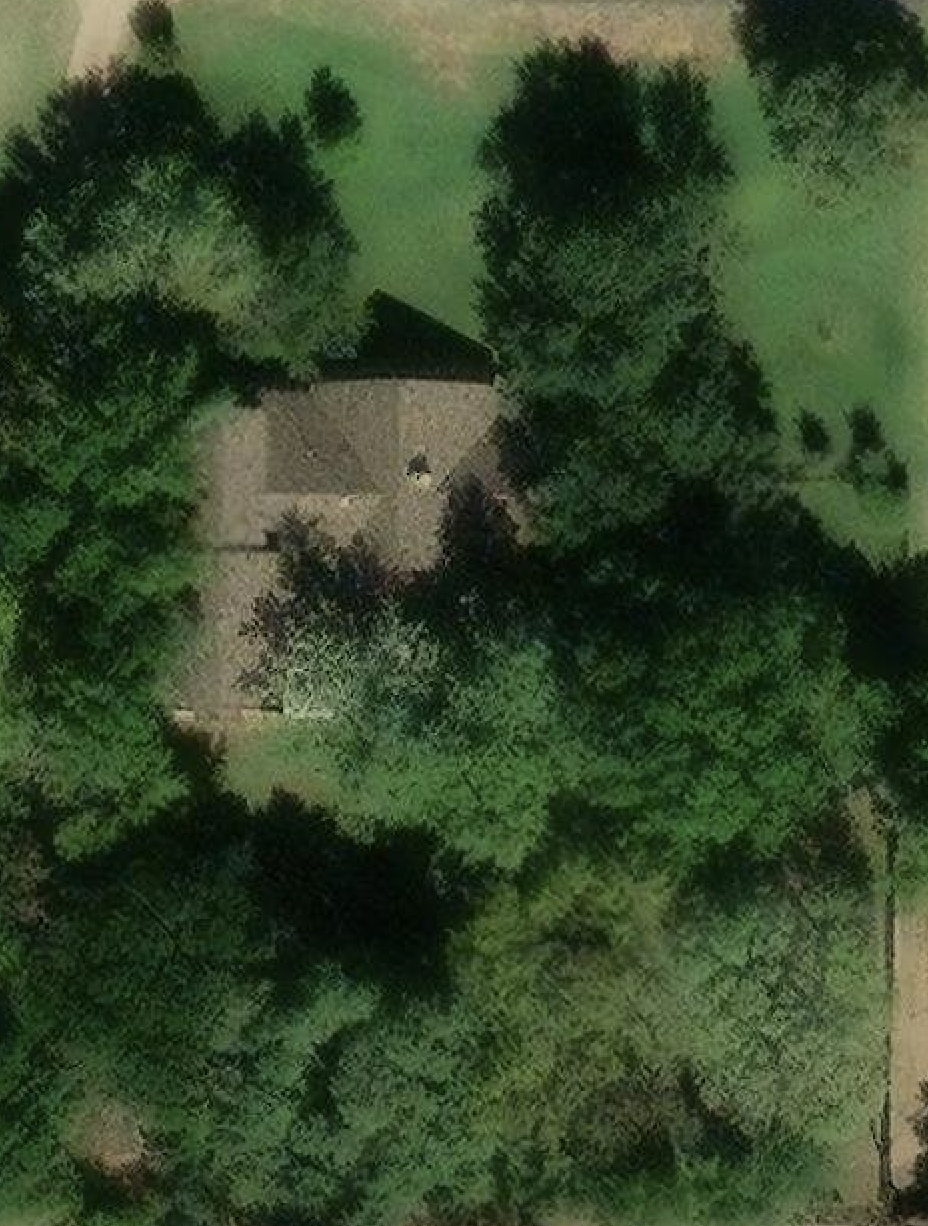

In [3]:
from IPython.display import Image as IPyImage

IPyImage(filename=prop1, width=400)

## Naive prompt

Same lesson as text: a vague ask gives a vague (or unreliable) answer. A one-line "give me a score" leaves too much unspecified.

In [4]:
messages = []
add_user_message(messages, [
    image_block(prop1),
    {"type": "text", "text": "Provide a fire risk score (1-4) for this property."},
])

print(text_from_message(chat(messages)))

# Fire Risk Score: **2 (Low-Moderate Risk)**

## Analysis:

**Positive factors (Lower Risk):**
- Dense forest canopy provides natural moisture retention
- Well-established, mature coniferous trees
- Appears to be in a temperate climate with adequate vegetation

**Risk factors (Moderate Concern):**
- Building surrounded by dense trees with limited clearance
- Coniferous forest (higher fuel load and flammability)
- Limited defensible space immediately around the structure
- Roof appears dark (may accumulate debris)
- Dense vegetation could impede emergency vehicle access

## Recommendations to reduce risk:
1. Create 30+ feet of defensible space around the structure
2. Remove dead/diseased trees and lower branches
3. Clear roof and gutters regularly
4. Trim tree branches overhanging the roof
5. Ensure clear access roads for emergency vehicles
6. Use fire-resistant roofing materials

The property's main vulnerability is the close proximity of dense forest with insufficient defensible space

## Structured prompt — fire risk assessment

The same prompt-engineering techniques that work for text work for images: give Claude a **step-by-step methodology**, explicit rating criteria, and a defined output. This is the insurance use case — assess wildfire risk from satellite imagery instead of dispatching an inspector.

In [5]:
prompt = """
Analyze the attached satellite image of a property with these specific steps:

1. Residence identification: Locate the primary residence on the property by looking for:
   - The largest roofed structure
   - Typical residential features (driveway connection, regular geometry)
   - Distinction from other structures (garages, sheds, pools)
   Describe the residence's location relative to property boundaries and other features.

2. Tree overhang analysis: Examine all trees near the primary residence:
   - Identify any trees whose canopy extends directly over any portion of the roof
   - Estimate the percentage of roof covered by overhanging branches (0-25%, 25-50%, 50-75%, 75-100%)
   - Note particularly dense areas of overhang

3. Fire risk assessment: For any overhanging trees, evaluate:
   - Potential wildfire vulnerability (ember catch points, continuous fuel paths to structure)
   - Proximity to chimneys, vents, or other roof openings if visible
   - Areas where branches create a "bridge" between wildland vegetation and the structure

4. Defensible space identification: Assess the property's overall vegetative structure:
   - Identify if trees connect to form a continuous canopy over or near the home
   - Note any obvious fuel ladders (vegetation that can carry fire from ground to tree to roof)

5. Fire risk rating: Based on your analysis, assign a Fire Risk Rating from 1-4:
   - Rating 1 (Low Risk): No tree branches overhanging the roof, good defensible space around the structure
   - Rating 2 (Moderate Risk): Minimal overhang (<25% of roof), some separation between tree canopies
   - Rating 3 (High Risk): Significant overhang (25-50% of roof), connected tree canopies, multiple points of vulnerability
   - Rating 4 (Severe Risk): Extensive overhang (>50% of roof), dense vegetation against structure, numerous ember catch points, limited defensible space

For each item above (1-5), write one sentence summarizing your findings, with your final response being the numeric Fire Risk Rating (1-4) with a brief justification.
"""

messages = []
add_user_message(messages, [
    image_block(prop1),
    {"type": "text", "text": prompt},
])

print(text_from_message(chat(messages)))

# Satellite Image Fire Risk Analysis

1. **Residence Identification**: The primary residence is the tan/beige-colored structure with a peaked roof visible in the center of the image, surrounded by dense coniferous forest on all sides with no visible driveway or clear property boundary demarcation.

2. **Tree Overhang Analysis**: Approximately 60-75% of the roof is directly covered or immediately overshadowed by dense coniferous tree canopy, with particularly thick overhang visible on the northern and eastern portions of the structure where tree crowns extend directly above the roofline.

3. **Fire Risk Assessment**: The overhanging trees create severe vulnerability as branches appear to directly contact or hover mere feet above roof surfaces, establishing direct fuel pathways from the surrounding forest canopy to the structure with multiple potential ember catch points around the roof perimeter.

4. **Defensible Space Identification**: There is minimal to no defensible space around thi

## Try another property

The same structured prompt generalizes — swap the image. (There are `prop1`–`prop7.png`; change the file to compare ratings.)

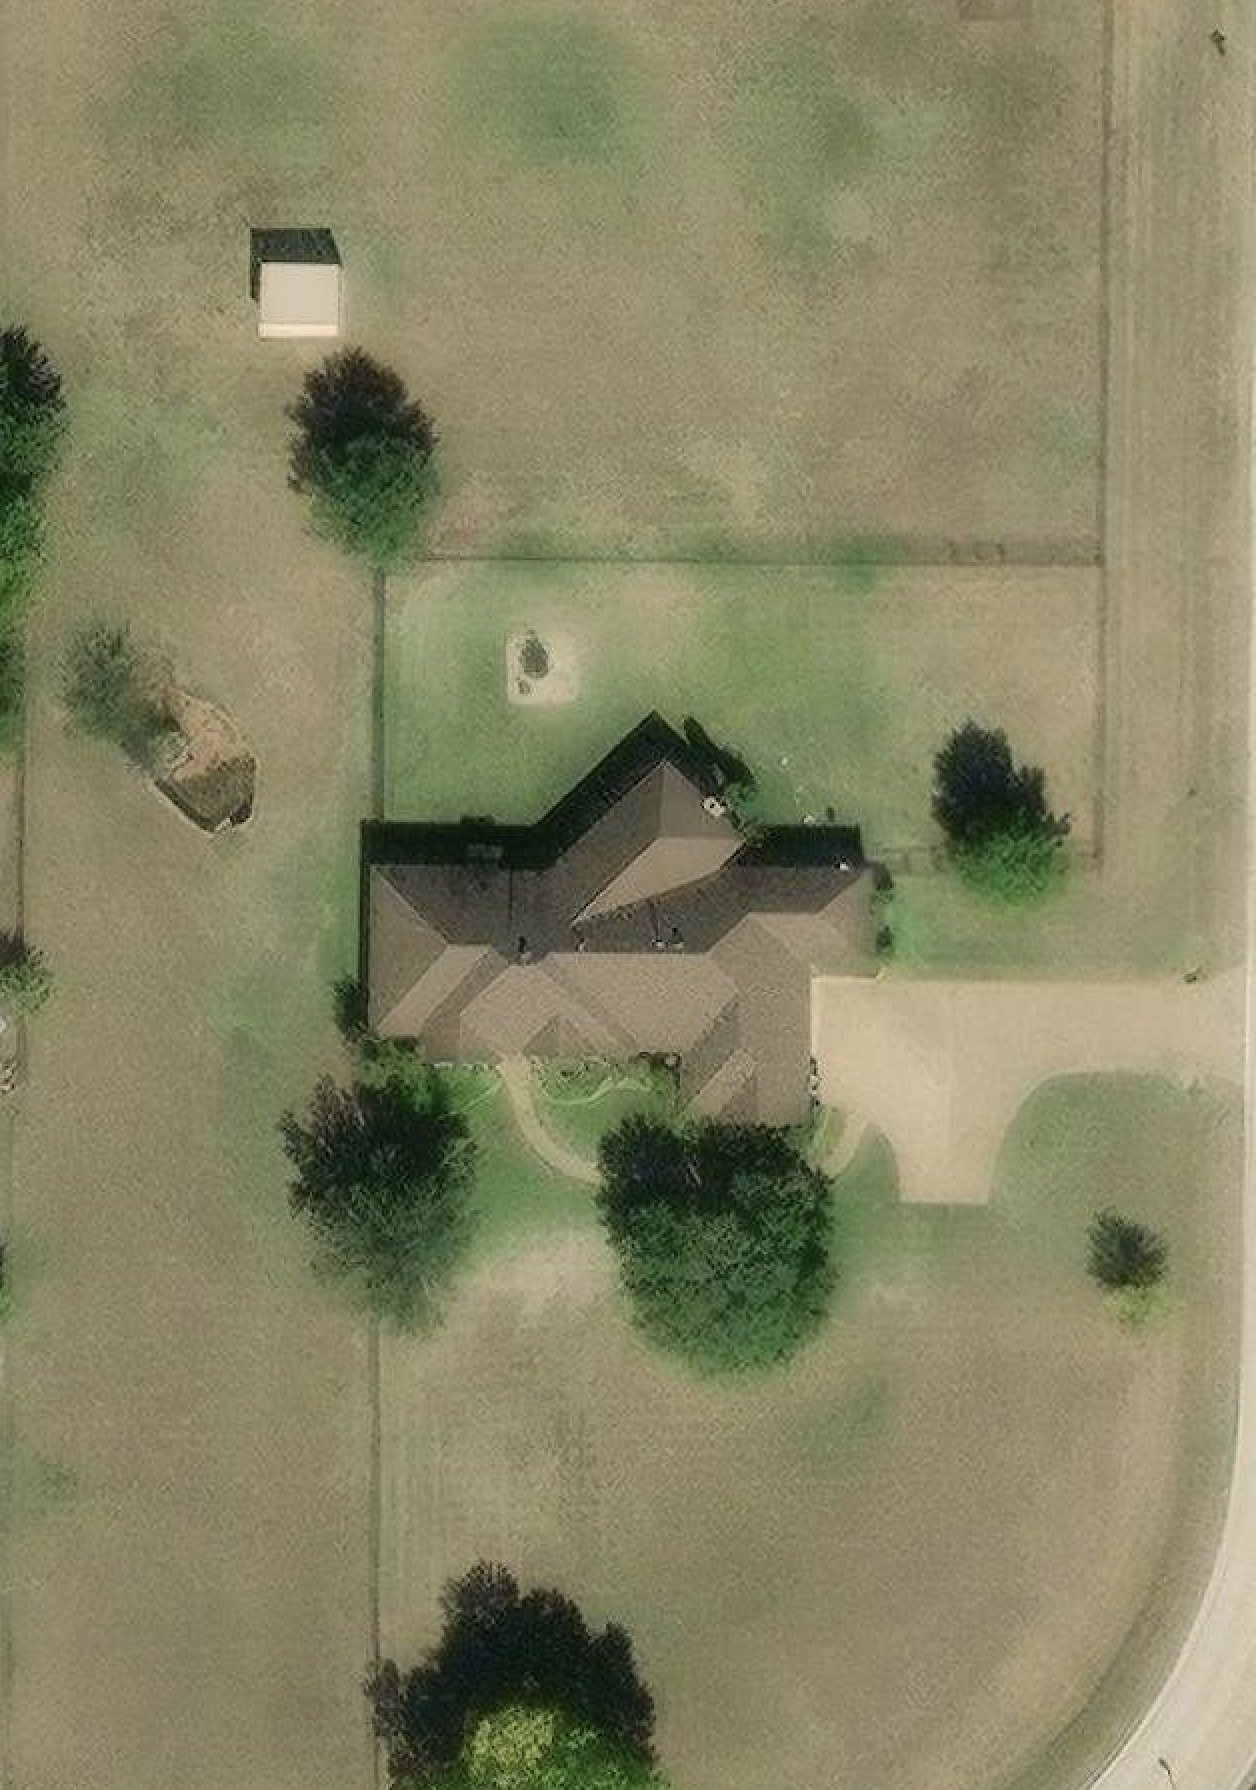

# Satellite Image Fire Risk Analysis

1. **Residence Identification:** The primary residence is the large, multi-roofed structure in the center of the property with tan/beige colored roofing, positioned roughly in the middle of the lot with a driveway connecting to the road on the right (east) side, and is clearly distinguishable from the small outbuilding visible in the upper (north) portion of the property.

2. **Tree Overhang Analysis:** Multiple trees are positioned around the residence with several showing canopy extension toward the structure; the most significant overhang appears on the north and west sides of the home, with dense vegetation covering an estimated 25-40% of the roof area, particularly concentrated over the northern roofline.

3. **Fire Risk Assessment:** The trees nearest the structure create potential ember catch points and fuel pathways, with particularly dense foliage on the north and west sides where branches appear to reach directly over roof sections; no ch

In [6]:
prop = os.path.join(IMAGES, "prop4.png")
display(IPyImage(filename=prop, width=400))

messages = []
add_user_message(messages, [
    image_block(prop),
    {"type": "text", "text": prompt},
])

print(text_from_message(chat(messages)))

## Prompting techniques for images

Everything from the prompt-engineering section transfers:

- **Provide a methodology** — number the analysis steps (as above) instead of asking a bare question.
- **Give a verification step** — e.g. for counting: *"count each item once and assign it a number, then recount bottom-left → right, row by row."* (This is how you'd fix the classic "how many marbles?" undercount — no marbles image here, but the technique is identical.)
- **One-shot / multi-shot** — include a *reference image with a known answer*, state it, then ask about the target image, so Claude has a calibration point.
- **Break complex tasks into smaller steps** and define the exact output shape.

**Takeaway:** vision quality tracks prompt quality. Invest in detailed, structured prompts — the same as with text — rather than one-line questions.

Next: **PDF support** — sending documents (text + page images) to Claude.